In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib
import time

In [15]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [18]:
search_spaces = {
    'learning_rate': Real(0.01, 0.2, 'log-uniform'),
    'max_depth': Integer(3, 12),
    'min_child_weight': Integer(1, 20),
    'subsample': Real(0.5, 1.0, 'uniform'),
    'colsample_bytree': Real(0.5, 1.0, 'uniform'),
    'gamma': Real(0, 1, 'uniform'),
    'reg_alpha': Real(1e-3, 100, 'log-uniform'),
    'reg_lambda': Real(1e-3, 100, 'log-uniform'),
}

In [19]:
opt = BayesSearchCV(
    estimator=XGBRegressor(
        objective='reg:absoluteerror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        n_estimators=5000,
        early_stopping_rounds=50,
        eval_metric='mae'
    ),
    search_spaces=search_spaces,
    n_iter=50,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=3,
    random_state=42
)

In [20]:
print("Starting hyperparameter tuning...")
start_time = time.time()

opt.fit(
    X_train_main, y_train_main,
    eval_set=[(X_val, y_val)],
    verbose=0
)
print(f"Tuning completed in {time.time()-start_time:.2f} seconds")
print("Best parameters found:")
print(opt.best_params_)


Starting hyperparameter tuning...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-114.829 total time=   2.1s
[CV 2/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-129.526 total time=   1.9s
[CV 3/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-119.921 total time=   3.3s
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END colsample_bytree

In [ ]:
best_xgb = opt.best_estimator_
# Train final model on full training data with early stopping
best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-mae:1499.40948
[100]	validation_0-mae:145.05493
[200]	validation_0-mae:82.49833
[300]	validation_0-mae:71.50530
[400]	validation_0-mae:65.73726
[500]	validation_0-mae:62.21133
[600]	validation_0-mae:59.90244
[700]	validation_0-mae:58.10369
[800]	validation_0-mae:56.56976
[900]	validation_0-mae:55.33047
[1000]	validation_0-mae:54.21194
[1100]	validation_0-mae:53.46378
[1200]	validation_0-mae:52.78198
[1300]	validation_0-mae:52.08703
[1400]	validation_0-mae:51.45185
[1500]	validation_0-mae:50.96179
[1600]	validation_0-mae:50.53002
[1700]	validation_0-mae:50.12902
[1800]	validation_0-mae:49.73386
[1900]	validation_0-mae:49.38463
[2000]	validation_0-mae:49.01679
[2100]	validation_0-mae:48.63614
[2200]	validation_0-mae:48.28177
[2300]	validation_0-mae:47.98243
[2400]	validation_0-mae:47.73599
[2500]	validation_0-mae:47.53649
[2600]	validation_0-mae:47.36332
[2700]	validation_0-mae:47.19755
[2800]	validation_0-mae:46.97042
[2900]	validation_0-mae:46.77963
[3000]	validation_0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8802605927470397, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='mae', feature_types=None, feature_weights=None,
             gamma=0.433146660867192, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.031093356962478034,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [22]:
y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

In [23]:
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{set_name} Metrics:")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    if set_name == "Test":
        print(f"Avg Price: {y_true.mean():.2f}")
    return mae

In [24]:
train_mae = print_metrics(y_train, y_pred_train, "Train")
test_mae = print_metrics(y_test, y_pred_test, "Test")


Train Metrics:
R²: 0.9968
MAE: 46.54
MAPE: 5.43%

Test Metrics:
R²: 0.9920
MAE: 96.92
MAPE: 7.28%
Avg Price: 2074.79


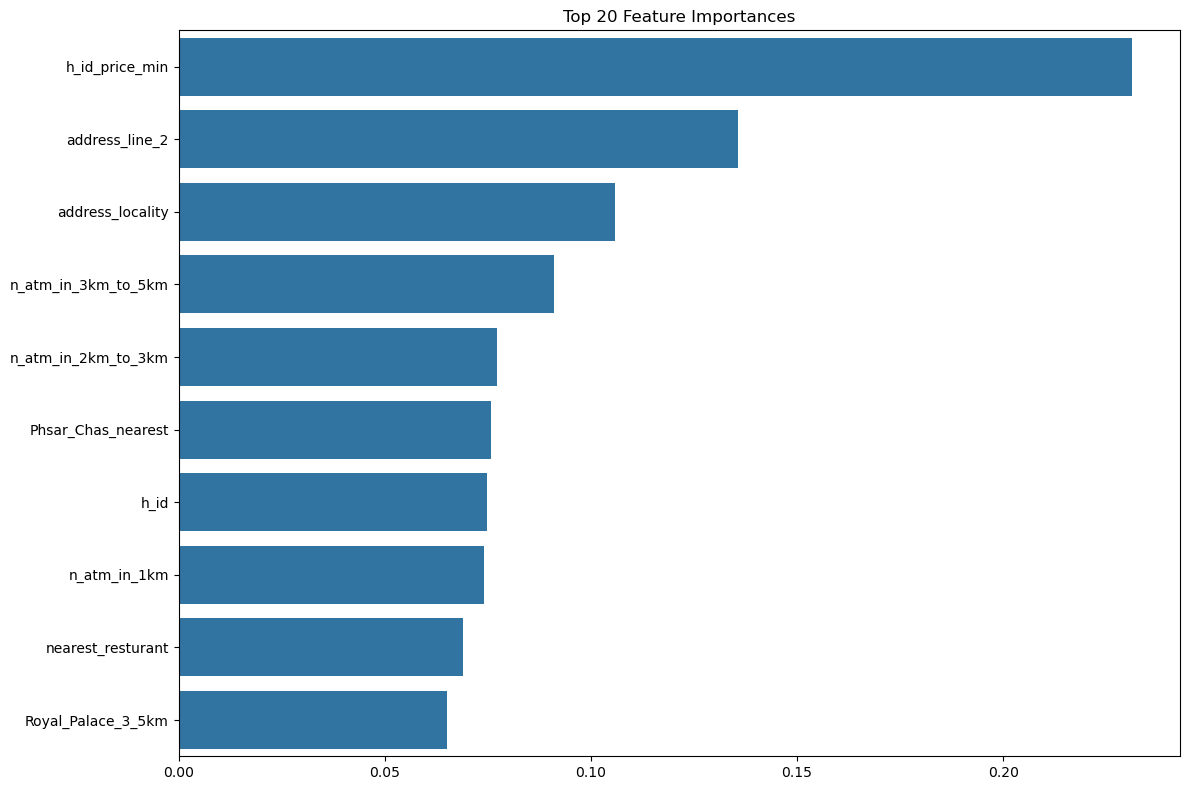

In [25]:
feature_importance = best_xgb.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [X.columns[i] for i in sorted_idx]

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance[sorted_idx][:20], y=sorted_features[:20])
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig("xgboost_feature_importances.png", dpi=300)
plt.show()

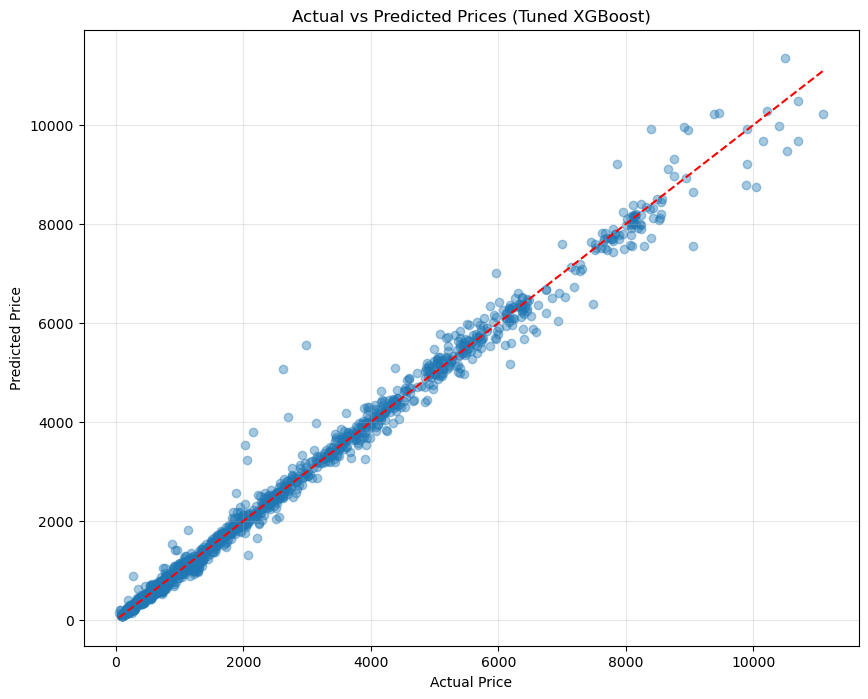

In [26]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Tuned XGBoost)")
plt.grid(alpha=0.3)
plt.savefig("tuned_xgboost_actual_vs_predicted.png", dpi=300)
plt.show()

In [31]:
def calculate_metrics(model, X_train, y_train, X_test, y_test, cv_folds=5):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2]
    })
    
    return metrics_df.round(4)

In [32]:
metrics_df = calculate_metrics(best_xgb, X_train, y_train, X_test, y_test)
print("\nModel Performance Metrics:")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)


Model Performance Metrics:
  Metric    Value
R2(Test)   0.9920
     MAE  96.9227
    RMSE 203.1532
    MAPE   7.2788
Train R2   0.9968


In [27]:
joblib.dump(best_xgb, "../../../models/xgboost/xgboost_model_label_v3.joblib")

['../../../models/xgboost/xgboost_model_label_v3.joblib']